## Gráficos con la información del análisis

### Carga del dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../dataset/stackoverflow_limpio.csv", 
                 index_col="question_id", 
                 parse_dates=["creation_date"])
print("Running")

Running


### Gráfica de preguntas por lenguaje de programación

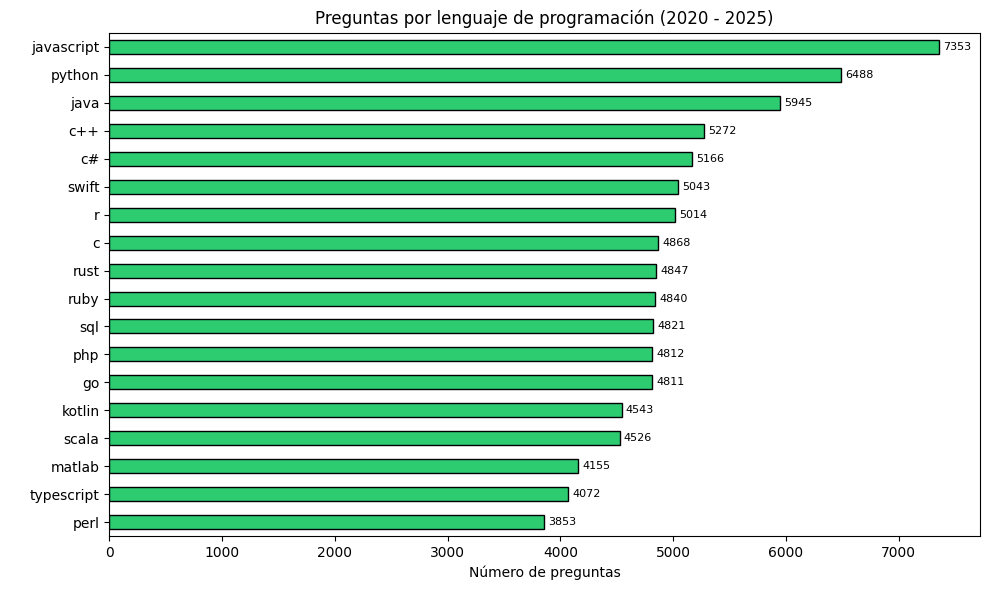

<Axes: title={'center': 'Preguntas por lenguaje de programación (2020 - 2025)'}, xlabel='Número de preguntas', ylabel=' '>

In [37]:
ax= df["programming_language"].value_counts() \
    .sort_values(ascending=True) \
    .plot(kind="barh", color="#2ecc71", edgecolor="black", title="Preguntas por lenguaje de programación (2020 - 2025)", figsize=(10, 6))



ax.set_xlabel('Número de preguntas')
ax.set_ylabel(' ')
ax.bar_label(ax.containers[0], padding=3, fontsize=8)

plt.tight_layout()
plt.savefig("../graficos/01_preguntas_por_lenguaje.png", dpi=150)
plt.show()

ax

### Gráfica de número de vistas promedio por vistas en cada lenguaje de programación

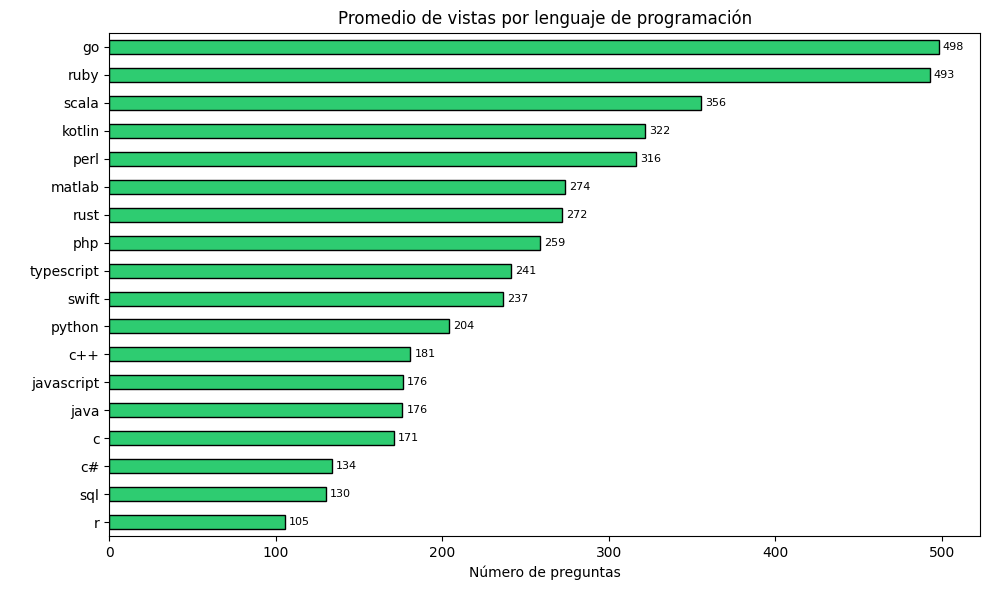

<Axes: title={'center': 'Promedio de vistas por lenguaje de programación'}, xlabel='Número de preguntas', ylabel=' '>

In [63]:
ax = df.groupby("programming_language")["view_count"] \
    .mean() \
    .sort_values(ascending=True) \
    .plot(kind="barh", color="#2ecc71", edgecolor="black", title="Promedio de vistas por lenguaje de programación", figsize=(10, 6))



ax.set_xlabel('Número de preguntas')
ax.set_ylabel(' ')
ax.bar_label(ax.containers[0], fmt="%.0f", padding=3, fontsize=8)

plt.tight_layout()
plt.savefig("../graficos/02_numero_de_vistas_por_pregunta.png", dpi=150)
plt.show()

ax

### Gráfico crecimiento de los lenguajes de programación con mayor indice de crecimiento (2023 - 2025)

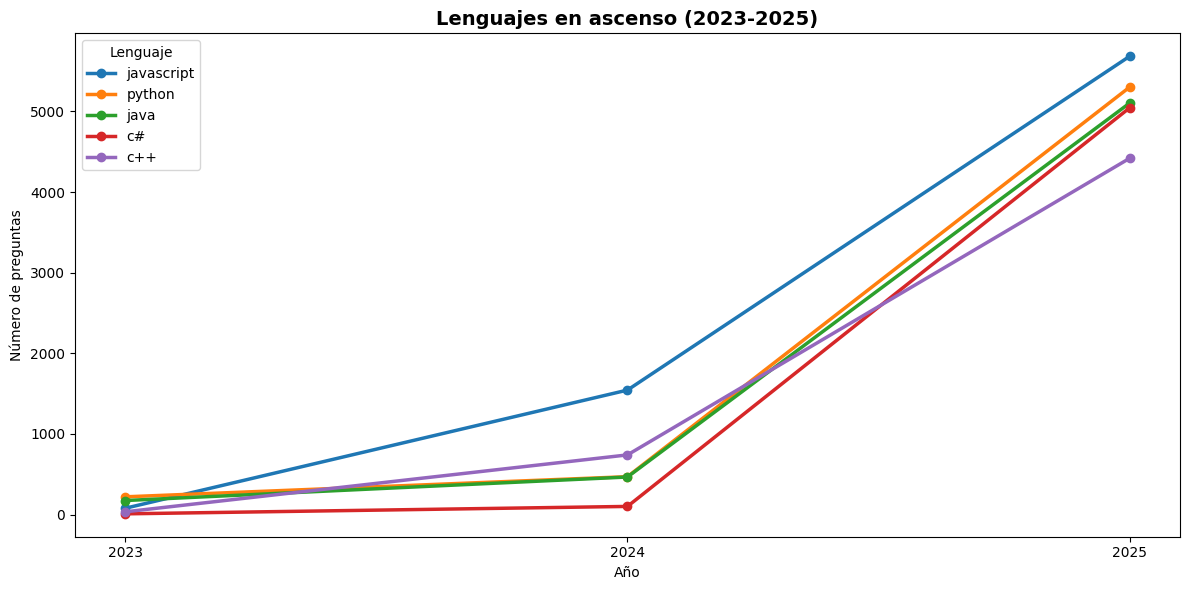

In [67]:
# Preguntas por lenguaje por año
crecimiento = df.groupby([
            df["creation_date"].dt.year,
            "programming_language"
])["programming_language"].count().unstack()

# Lenguajes en ascenso
ascenso = ["javascript", "python", "java", "c#", "c++"]

ax= crecimiento[ascenso].loc[2023:2025].plot(
    kind="line", marker="o", linewidth=2.5, figsize=(12, 6)
)

ax.set_title("Lenguajes en ascenso (2023-2025)", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Número de preguntas")
ax.legend(title="Lenguaje", )
ax.set_xticks([2023, 2024, 2025])

plt.tight_layout()
plt.savefig("../graficos/03_lenguajes_ascenso.png", dpi=150, bbox_inches="tight")
plt.show()

### Gráfico crecimiento de los lenguajes de programación con menor indice de crecimiento (2023 - 2025)

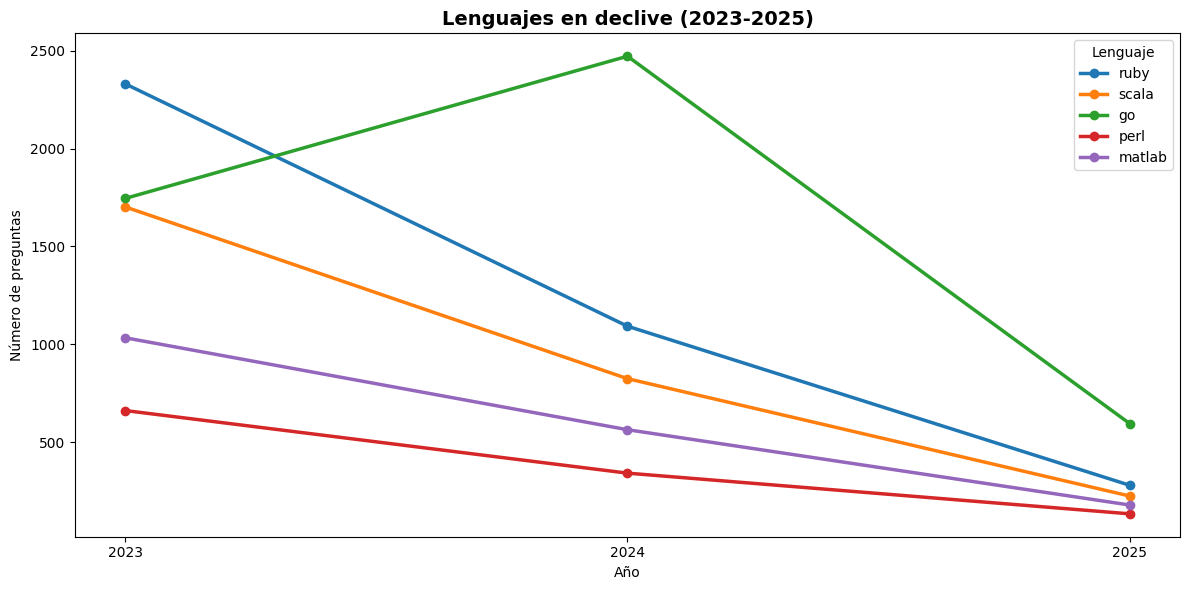

In [70]:
# Lenguajes en descenso
declive = ["ruby", "scala", "go", "perl", "matlab"]

ax= crecimiento[declive].loc[2023:2025].plot(
    kind="line", marker="o", linewidth=2.5, figsize=(12, 6)
)

ax.set_title("Lenguajes en declive (2023-2025)", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Año")
ax.set_ylabel("Número de preguntas")
ax.legend(title="Lenguaje", )
ax.set_xticks([2023, 2024, 2025])

plt.tight_layout()
plt.savefig("../graficos/04_lenguajes_declive.png", dpi=150, bbox_inches="tight")
plt.show()

### Comunidad de cada lenguaje

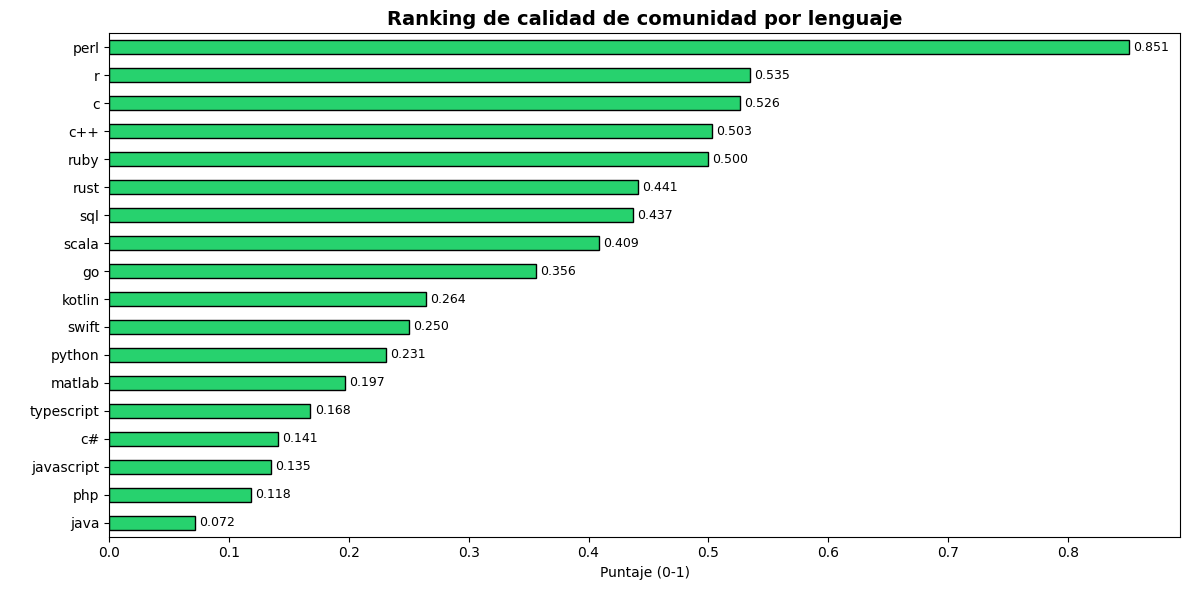

In [82]:
community = df.groupby("programming_language").agg(
    views        = ("view_count", "mean"),
    score         = ("score", "mean"),
    responses    = ("answer_count", "mean"),
    answered    = ("is_answered", "mean"),
    accepted      = ("has_accepted_answer", "mean")
).round(3)
  
# Normalizar cada métrica a escala 0-1
community_norm = (community - community.min()) / (community.max() - community.min())

# Puntaje final de community (promedio de las 5 métricas normalizadas)
community_norm["community_score"] = community_norm.mean(axis=1).round(3)

# Ranking final
ranking_community = community_norm["community_score"] \
    .sort_values(ascending=True)

ax = ranking_community.plot(kind="barh",color="#27d26e", edgecolor="black", figsize=(12, 6))

ax.set_title("Ranking de calidad de comunidad por lenguaje", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Puntaje (0-1)")
ax.set_ylabel(" ")
ax.bar_label(ax.containers[0], fmt="%.3f", padding=3, fontsize=9)

plt.tight_layout()
plt.savefig("../graficos/05_ranking_comunidad.png", dpi=150)
plt.show()